## Introduction

Equity factors are specific, measurable characteristics of stocks—such as value, quality, momentum, size, volatility, and growth—that explain risk and return drivers beyond traditional market indexing. This project constructs five style factors from raw market data, stores them in a PostgreSQL database, and rigorously evaluates their predictive power using standard quantitative research methodology.

The analysis covers the S&P 500 universe using daily price data from 2021 to 2026 (~500 tickers, sourced via yfinance) and quarterly fundamental data from mid-2024 onward (income statements and balance sheets). Factor returns are benchmarked against published Fama-French factors from the Kenneth French Data Library. Key limitations include survivorship bias (only current index constituents are used), a short fundamental data window (~5-6 quarters), and a large-cap-only universe where some factor premiums are known to be weaker.

## Data & Methodology

### Universe and Data Sources

The investment universe consists of S&P 500 constituents as of the analysis date. Daily price data (open, high, low, adjusted close, volume) was downloaded via yfinance and stored in a PostgreSQL database. Quarterly fundamental data (net income, total revenue, stockholders' equity, total debt, ordinary shares outstanding) was sourced from yfinance financial statements. Fama-French daily factor returns (MKT-RF, SMB, HML, UMD, RF) were downloaded from the Kenneth French Data Library and compounded to monthly frequency.

SQL views transform the raw data into analytical building blocks: monthly returns (last trading day close-to-close), forward returns (next month's return, used to avoid look-ahead bias), and derived fundamentals (ROE, debt-to-equity, and market capitalization computed from raw inputs). All factor evaluations use forward returns — stocks are scored at the end of month T and evaluated on their performance in month T+1.

### Factor Definitions

Five factors are constructed from the raw data:

- **Momentum (12-1):** Cumulative compounded return over months T-12 to T-2, skipping the most recent month to avoid short-term reversal effects. Higher past returns signal continued outperformance.
- **Value:** Book-to-market ratio (stockholders' equity / market capitalization). Higher values indicate cheaper stocks relative to their accounting value.
- **Size:** Negated market capitalization. Smaller companies receive higher scores, reflecting the academic finding that small-cap stocks tend to outperform.
- **Volatility:** Negated 252-day rolling standard deviation of daily returns. Lower volatility receives higher scores, reflecting the low-volatility anomaly.
- **Quality:** Return on equity (net income / stockholders' equity). Higher profitability signals a stronger business.

Each factor's raw scores are z-score normalized cross-sectionally (across all stocks on a given date) and assigned to quintiles (1 = lowest score, 5 = highest). Price-based factors (momentum, volatility) use the full ~5-year price history. Fundamental-based factors (value, size, quality) are limited to ~5-6 quarters of data, with quarterly values forward-filled to monthly frequency using the most recent available report.

### Evaluation Methodology

Factor performance is assessed through four lenses:

**Information Coefficient (IC):** The Spearman rank correlation between factor scores at time T and stock returns at time T+1, computed monthly. Mean IC, standard deviation, information ratio (mean IC / std), and hit rate (percentage of months with positive IC) summarize each factor's predictive consistency.

**Quintile Spread Analysis:** Each month, stocks are sorted into five quintiles by factor score. The average forward return per quintile is computed across all months. A monotonic increase from Q1 to Q5 indicates the factor differentiates returns effectively.

**Long-Short Backtest:** A portfolio goes long the top quintile (Q5) and short the bottom quintile (Q1), rebalanced monthly. Cumulative returns, annualized Sharpe ratio, and maximum drawdown are computed. Portfolio turnover is measured and transaction costs are modeled at 10 basis points per trade.

**Statistical Significance:** Mean long-short returns are tested against zero using OLS regression with Newey-West (HAC) standard errors (6 lags) to correct for autocorrelation in monthly return series. P-values are adjusted for multiple hypothesis testing using both Bonferroni correction and Benjamini-Hochberg false discovery rate control.

### Bias Awareness

- **Survivorship bias:** The universe uses current S&P 500 constituents. Companies that were delisted or removed from the index are absent, which may overstate factor returns. Point-in-time constituent data would address this but is not freely available.
- **Look-ahead bias:** All factor scores use only data available at the time of scoring. Fundamental data is aligned using the most recent quarterly report on or before the scoring date, and factor performance is measured using forward (next-month) returns.

## Results

### Factor Correlations

Before evaluating individual factor performance, we examine how the five factors relate to each other. Independent factors provide diversified sources of return; highly correlated factors are capturing the same signal.

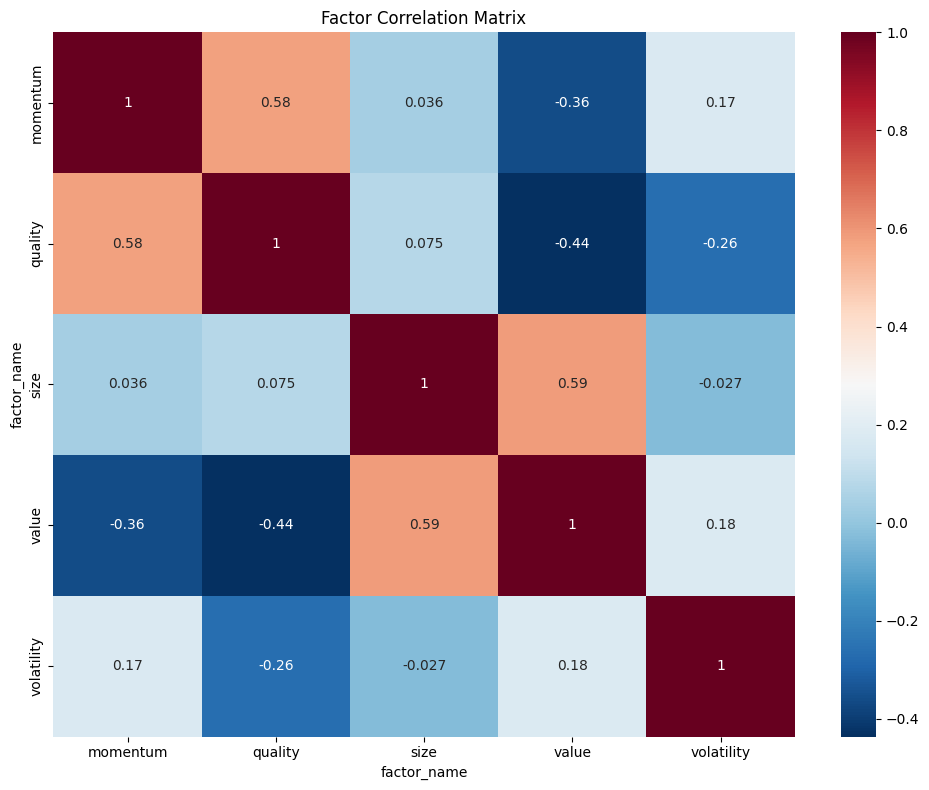

In [1]:
from analysis.correlation_analysis import compute_factor_correlations, plot_correlation_heatmap
from config.settings import engine, PROJECT_ROOT

corr, overlap = compute_factor_correlations(engine)
_ = plot_correlation_heatmap(corr)

The fundamental-dependent factors (size, value, quality) show moderate to high correlations — size and value at 0.59, quality and value at -0.44. Momentum and quality show a notable positive correlation of 0.58, suggesting that recent winners in this period also tended to be higher-ROE companies. The price-based factors (momentum, volatility) remain relatively independent at 0.17. These correlations are estimated from a limited overlapping window, so they should be interpreted as indicative rather than definitive — the overlap matrix below shows the number of shared months behind each pair.

In [2]:
print(overlap)

factor_name  momentum  quality  size  value  volatility
factor_name                                            
momentum           49       18    18     18          49
quality            18       18    18     18          18
size               18       18    18     18          18
value              18       18    18     18          18
volatility         49       18    18     18          49


### Information Coefficient Analysis

The Information Coefficient (IC) measures the Spearman rank correlation between factor scores at time T and realized stock returns at time T+1. A consistently positive IC indicates that higher factor scores predict higher future returns. Mean IC, standard deviation, information ratio (mean/std), and hit rate (percentage of months with IC > 0) summarize each factor's predictive consistency.

                 mean       std  count        ir  hit_rate
factor_name                                               
momentum     0.022370  0.180139     48  0.124182  0.604167
quality     -0.011348  0.094145     16 -0.120534  0.375000
size         0.023206  0.130214     16  0.178217  0.437500
value        0.046175  0.185307     16  0.249183  0.750000
volatility  -0.035141  0.265581     48 -0.132318  0.395833


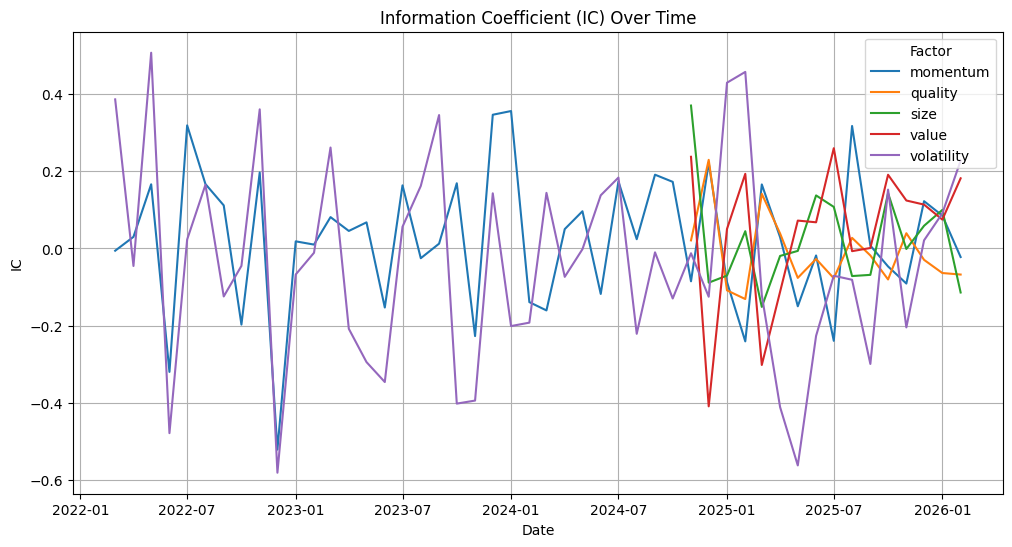

In [3]:
from analysis.factor_evaluation import compute_ic_series, plot_ic_series

df_ic = compute_ic_series(engine)
print(df_ic.groupby('factor_name')['ic'].agg(['mean', 'std', 'count']).assign(ir = lambda x: x['mean'] / x['std'], hit_rate = df_ic.groupby('factor_name')['ic'].apply(lambda x: (x > 0).mean())))
plot_ic_series(df_ic)

Value shows the strongest predictive signal with a mean IC of 0.046, a hit rate of 75%, and the highest information ratio (0.25). Momentum is positive but noisier (mean IC 0.022, hit rate 60%). Size shows a weak positive signal (mean IC 0.023) but with a low hit rate of 44%, suggesting inconsistent prediction. Quality and volatility have negative mean ICs, indicating their scoring direction did not predict forward returns in this sample.

The IC time series reveals high month-to-month variability across all factors — this is typical of single-factor signals in equity markets. The fundamental factors (quality, size, value) only appear from mid-2024 onward, reflecting the limited availability of free fundamental data.

### Quintile Spread Analysis

Stocks are sorted into five quintiles by factor score each month. The chart below shows the average forward monthly return per quintile, averaged across all months. A monotonic increase from Q1 to Q5 indicates effective return differentiation.

quintile            1         2         3         4         5
factor_name                                                  
momentum     0.008007  0.008307  0.008299  0.010269  0.015616
quality      0.010501  0.006309  0.009023  0.006061  0.013040
size         0.003841  0.004042  0.010811  0.010006  0.016988
value        0.001607  0.010834  0.008856  0.008274  0.016726
volatility   0.020897  0.009846  0.009807  0.005605  0.004244


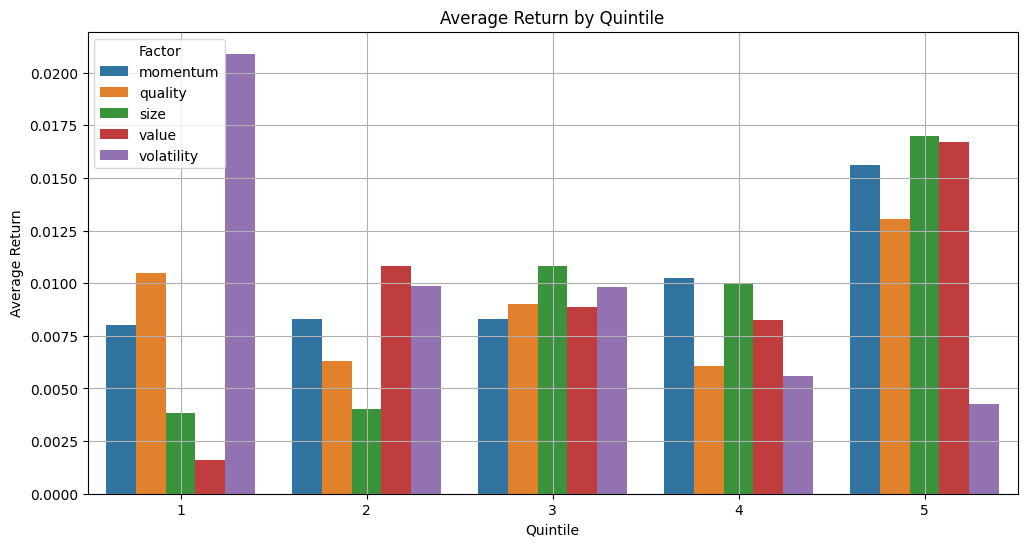

In [4]:
from analysis.factor_evaluation import compute_quintile_spreads, plot_quintile_spreads

df_qs = compute_quintile_spreads(engine)
print(df_qs)
plot_quintile_spreads(df_qs)

Momentum, value, and size show clear monotonic increases from Q1 to Q5, confirming that higher factor scores are associated with higher subsequent returns. Value shows the strongest Q5-Q1 spread. Quality shows a modest upward trend but with an elevated Q1 return, suggesting the signal is less clean. Volatility is inverted — high-volatility stocks (Q1, since scores are negated) outperformed low-volatility stocks (Q5), consistent with the negative IC finding.

### Cross-Validation Against Fama-French Factors

To validate the factor implementations, the long-short returns of momentum, size, and value are compared against their published Fama-French counterparts (UMD, SMB, and HML respectively). High correlation with the benchmark indicates the factor is capturing the intended signal. Differences are expected due to universe constraints (S&P 500 vs. full US market) and the short overlapping window.

In [5]:
from analysis.factor_evaluation import cross_validation

results = cross_validation(engine)
for factor, data in results.items():
    print(f"{factor}: correlation = {data['correlation']:.3f} ({data['months']} months)")

momentum: correlation = -0.115 (48 months)
size: correlation = 0.305 (17 months)
value: correlation = 0.093 (17 months)


Size shows the strongest correlation with its benchmark (SMB, 0.31), indicating the factor captures a similar signal despite the S&P 500-only universe. Value shows a weak positive correlation with HML (0.09), likely due to differences in how book value is sourced — yfinance fundamentals may differ from the Compustat data used by Fama-French. Momentum shows a surprising negative correlation with UMD (-0.12); however, the mean return and volatility of both series are comparable in magnitude, suggesting the implementation is not broken. The divergence is consistent with large-cap momentum behaving differently from broad-market momentum, particularly during the 2022-2023 rate-hiking cycle when market leadership shifted rapidly. All correlations should be interpreted cautiously given the short overlap — especially the 17-month window for fundamental-based factors.

### Backtest Performance

A long-short portfolio is constructed for each factor: going long the top quintile (Q5) and short the bottom quintile (Q1), rebalanced monthly. The chart below shows the cumulative return of each factor's long-short strategy over the sample period.

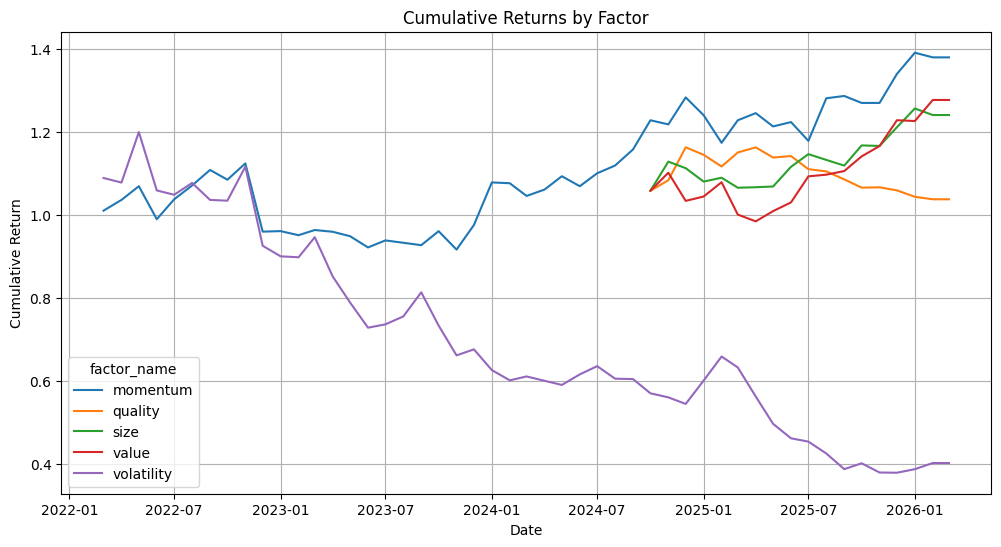

In [6]:
from analysis.backtest import compute_performance_metrics, compute_turnover, compute_cumulative_returns, plot_cumulative_returns

returns = compute_cumulative_returns(engine)

plot_cumulative_returns(returns)



In [7]:
compute_performance_metrics(engine)

,factor_name,total_return,annual_return,annual_sharpe,max_drawdown,n_months
0,momentum,0.378672,0.081817,0.615040,-0.184524,49
1,quality,0.037365,0.024757,0.297990,-0.107579,18
2,size,0.239988,0.154192,1.473597,-0.055653,18
3,value,0.276220,0.176568,1.354300,-0.106290,18
4,volatility,-0.597042,-0.199560,-0.879832,-0.683389,49


In [8]:
compute_turnover(engine)

,factor_name,avg_monthly_turnover
0,momentum,0.221197
1,quality,0.183489
2,size,0.128830
3,value,0.129081
4,volatility,0.057680


Momentum delivers the highest total return (37.9% over 49 months) with a Sharpe ratio of 0.62 and a manageable drawdown of -18.5%. However, it has the highest monthly turnover (22%), reflecting the rapidly shifting nature of price momentum.

Size and value show the strongest risk-adjusted performance with Sharpe ratios of 1.47 and 1.35 respectively, though these are estimated from only 18 months — too short to draw reliable conclusions. Both have moderate turnover (~13%) and contained drawdowns.

Quality is marginally positive (3.7% total return, Sharpe 0.30) with the second-highest turnover (18%). The weak performance is consistent with its negative IC.

Volatility is the worst performer, losing 59.7% cumulatively with a maximum drawdown of -68.3% and a negative Sharpe of -0.88. The low-volatility anomaly ran in reverse during this period — high-volatility stocks consistently outperformed. Its low turnover (5.8%) means transaction costs are minimal, but this provides no comfort given the magnitude of losses.

Transaction costs at 10 basis points per trade reduce annual returns by 0.1–0.5% depending on turnover. For all factors, the cost drag is small relative to the factor returns themselves — signal strength, not execution cost, is the binding constraint.

### Statistical Significance

Mean long-short returns are tested against zero using OLS with Newey-West standard errors (6 lags) to account for autocorrelation in monthly returns. P-values are then adjusted for multiple hypothesis testing using both Bonferroni correction and Benjamini-Hochberg FDR.

In [9]:
from analysis.factor_evaluation import compute_significance

df_s =compute_significance(engine)
df_s

,factor_name,mean_return,nw_tstat,nw_pvalue,n_months,significant,bonferroni_p,bh_p
0,momentum,0.007453,1.558056,0.119220,49,False,0.596100,0.149025
1,quality,0.002398,0.280003,0.779475,18,False,1.000000,0.779475
2,size,0.012416,2.700137,0.006931,18,True,0.034655,0.034655
3,value,0.014280,2.004567,0.045009,18,True,0.225047,0.075016
4,volatility,-0.016314,-2.131576,0.033042,49,True,0.165208,0.075016


Before correction, size (p=0.007), volatility (p=0.033), and value (p=0.045) show statistically significant mean returns — though volatility's significance is in the negative direction. After Bonferroni correction, only size survives (adjusted p=0.035). Under the less conservative Benjamini-Hochberg procedure, size remains significant (p=0.035) and value is borderline (p=0.075). Momentum, despite being the highest total return factor, does not reach significance (p=0.12), illustrating that economic magnitude and statistical significance are distinct questions. These results underscore both the value of proper multiple testing correction and the challenge of identifying reliable factor premiums from limited samples.

## Conclusions

### Key Findings

Value and momentum emerged as the most promising factors in this analysis. Value showed the strongest Information Coefficient (mean IC 0.046, 75% hit rate), the best risk-adjusted performance among fundamental factors (Sharpe 1.35), and retained borderline significance after multiple hypothesis correction. Momentum delivered the highest cumulative return (37.9%) over the longest evaluation window (49 months) with a clear monotonic quintile spread, though it did not reach statistical significance.

Size showed strong risk-adjusted returns (Sharpe 1.47) and was the only factor to survive Bonferroni correction, but this result is based on just 18 months of data and should be treated with caution. Quality produced weak, inconsistent results. Volatility performed worst — the low-volatility anomaly ran decisively in reverse, with high-volatility stocks outperforming throughout the sample period.

### Limitations

Several constraints affect the reliability of these findings:

The S&P 500 universe limits the analysis to large-cap stocks, where factor premiums are known to be weaker than in the broader market. Free fundamental data from yfinance covers only 5–6 quarters, restricting fundamental-dependent factors (value, size, quality) to approximately 18 months of evaluation — too short for robust statistical inference. Survivorship bias is present because only current index constituents are included; companies that were removed or delisted are absent from the data. Finally, the sample period (2022–2026) coincides with an unusual macroeconomic environment — aggressive rate hikes, concentrated tech leadership, and elevated volatility — which may not be representative of long-term factor behavior.

### What I Would Do With Better Data and More Time

With access to point-in-time constituent data, the survivorship bias issue would be resolved and the analysis could extend to mid- and small-cap stocks where factor effects are stronger. A longer fundamental data history (10+ years from a provider like Compustat or FactSet) would provide the statistical power needed to draw more confident conclusions about value, size, and quality. Multi-factor combination and portfolio optimization — deliberately excluded from this project's scope — would be a natural next step, testing whether combining independent signals (e.g., momentum + value) improves risk-adjusted returns. Finally, deploying the Streamlit dashboard with live data updates would transform this from a static analysis into a monitoring tool.